In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("churn.csv")

In [3]:
# show column info
for col in df.columns:
    print(f"{col}\n")
    print(df[col].unique())
    print(df[col].info())
    print(f"{df[col].describe()}\n\n")

Unnamed: 0

[    0     1     2 ... 36989 36990 36991]
<class 'pandas.core.series.Series'>
RangeIndex: 36992 entries, 0 to 36991
Series name: Unnamed: 0
Non-Null Count  Dtype
--------------  -----
36992 non-null  int64
dtypes: int64(1)
memory usage: 289.1 KB
None
count    36992.000000
mean     18495.500000
std      10678.814916
min          0.000000
25%       9247.750000
50%      18495.500000
75%      27743.250000
max      36991.000000
Name: Unnamed: 0, dtype: float64


age

[18 32 44 37 31 13 21 42 45 25 60 11 34 40 16 57 39 33 30 19 48 43 29 10
 20 61 17 12 52 26 49 24 22 36 58 41 50 23 38 35 28 53 55 59 47 54 62 51
 56 27 14 46 15 64 63]
<class 'pandas.core.series.Series'>
RangeIndex: 36992 entries, 0 to 36991
Series name: age
Non-Null Count  Dtype
--------------  -----
36992 non-null  int64
dtypes: int64(1)
memory usage: 289.1 KB
None
count    36992.000000
mean        37.118161
std         15.867412
min         10.000000
25%         23.000000
50%         37.000000
75%         51.000

In [4]:
# identify dirty columns
for col in df.columns:
    if '?' in df[col].unique():
        print(f"? {col}")
    elif ' ' in df[col].unique():
        print(f" {col}")
    elif 'Error' in df[col].unique():
        print(f" error {col}")
    elif 'Unknown' in df[col].unique():
        print(f" unknown {col}")
# identify negative numeric columns
for col in df.columns:
    if df[col].dtype.kind in 'if':
        cont=True
        for x in df[col].unique():
            if(x<0 and cont):
                print(f"- {col}")
                cont=False
            elif(x==0 and cont):
                print(f"0 {col}")
                cont=False
df.isna().sum()

 unknown gender
? joined_through_referral
? medium_of_operation
 error avg_frequency_login_days
0 Unnamed: 0
- days_since_last_login
- avg_time_spent
- points_in_wallet
0 churn_risk_score


Unnamed: 0                         0
age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            288
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64

In [5]:
def clean(dt):
    data=dt.copy()
    data = data.drop(columns='Unnamed: 0', axis=1)
    data.loc[data['referral_id'] == 'xxxxxxxx', 'joined_through_referral'] = 'No'
    data.loc[data['referral_id'] != 'xxxxxxxx', 'joined_through_referral'] = 'Yes'
    data.loc[data['gender'] == 'Unknown', 'gender'] = data['gender'].mode()[0]
    data.loc[data['medium_of_operation'] == '?','medium_of_operation'] = data['medium_of_operation'].mode()[0]
# get median from valid login values
    temp=data[data['avg_frequency_login_days']!='Error']
# replace error values with median
    data.loc[data['avg_frequency_login_days']=='Error','avg_frequency_login_days']= pd.to_numeric(temp['avg_frequency_login_days']).median()
# drop impossible negative values
    data=data[data['days_since_last_login']>0]
    data=data[data['avg_time_spent']>0]
    data=data[data['points_in_wallet']>0]
# convert to numeric
    data['avg_frequency_login_days']=pd.to_numeric(data['avg_frequency_login_days'])
# drop negative average login values
    data=data[data['avg_frequency_login_days']>0]
# fill missing values with median
    data['avg_frequency_login_days']=data['avg_frequency_login_days'].fillna(data['avg_frequency_login_days'].median())
# drop also remaining missing values
    data=data.dropna()
# remove duplicate rows
    data = data.drop_duplicates()
    return data

In [6]:
def outlier_iqr(dt):
# remove outliers using IQR
    data=dt.copy()
    for col in data.columns:
        if data[col].dtype.kind in 'if':
            q1=data[col].quantile(0.25)
            q3=data[col].quantile(0.75)
            iqr=q3-q1
            upper_limit = q3+1.5*iqr
            lower_limit = q1-1.5*iqr
            data=data[(data[col] <= upper_limit)&(data[col] >= lower_limit)]
    return data

In [7]:
def perform_rfm_analysis(data):
    rfm_data = data.copy()
    
    rfm_data['Recency'] = rfm_data['days_since_last_login']

    rfm_data['Frequency'] = rfm_data['avg_frequency_login_days']
    
    rfm_data['Monetary'] = rfm_data['avg_transaction_value']
    rfm_data= rfm_data.drop(columns=['avg_transaction_value','avg_frequency_login_days','days_since_last_login'],axis=1)
    rfm_data = rfm_data[rfm_data['Monetary'] > 0]
    
    rfm_data['recency_score'] = pd.qcut(rfm_data['Recency'], 5, labels=[5,4,3,2,1])
    
    rfm_data['frequency_score'] = pd.qcut(
        rfm_data['Frequency'].rank(method='first', ascending=False), 
        5, 
        labels=[1, 2, 3, 4, 5]
    )
    
    rfm_data['monetary_score'] = pd.qcut(rfm_data['Monetary'], 5, labels=[1, 2, 3, 4, 5])
    
    rfm_data['RFM_SCORE'] = (
        rfm_data['recency_score'].astype(str) + 
        rfm_data['frequency_score'].astype(str) + 
        rfm_data['monetary_score'].astype(str)
    )
    
    seg_map = {
        r'[1-2][1-2][1-2]': 'Low Value',
        r'[1-2][1-2][3-5]': 'Price Sensitive',
        r'[1-2][3-5][1-2]': 'Promising',
        r'[1-2][3-5][3-5]': 'Potential Loyalists',
        r'[3-5][1-2][1-2]': 'Need Attention',
        r'[3-5][1-2][3-5]': 'At Risk',
        r'[3-5][3-5][1-2]': 'Loyal',
        r'[3-5][3-5][3-5]': 'Champions',
        r'5[4-5][4-5]': 'VIP',
        r'[4-5]5[4-5]': 'Super Users'
    }
    
    rfm_data['segment'] = rfm_data['RFM_SCORE']
    for pattern, segment in seg_map.items():
        mask = rfm_data['RFM_SCORE'].str.match(pattern)
        rfm_data.loc[mask, 'segment'] = segment
    
    return rfm_data

In [8]:
cleaned_df = clean(df)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24985 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           24985 non-null  int64  
 1   gender                        24985 non-null  object 
 2   security_no                   24985 non-null  object 
 3   region_category               24985 non-null  object 
 4   membership_category           24985 non-null  object 
 5   joining_date                  24985 non-null  object 
 6   joined_through_referral       24985 non-null  object 
 7   referral_id                   24985 non-null  object 
 8   preferred_offer_types         24985 non-null  object 
 9   medium_of_operation           24985 non-null  object 
 10  internet_option               24985 non-null  object 
 11  last_visit_time               24985 non-null  object 
 12  days_since_last_login         24985 non-null  int64  
 13  avg_ti

In [9]:
df_no_outliers = outlier_iqr(cleaned_df)
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19072 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           19072 non-null  int64  
 1   gender                        19072 non-null  object 
 2   security_no                   19072 non-null  object 
 3   region_category               19072 non-null  object 
 4   membership_category           19072 non-null  object 
 5   joining_date                  19072 non-null  object 
 6   joined_through_referral       19072 non-null  object 
 7   referral_id                   19072 non-null  object 
 8   preferred_offer_types         19072 non-null  object 
 9   medium_of_operation           19072 non-null  object 
 10  internet_option               19072 non-null  object 
 11  last_visit_time               19072 non-null  object 
 12  days_since_last_login         19072 non-null  int64  
 13  avg_ti

In [10]:
df_rfm=perform_rfm_analysis(df_no_outliers)
df_rfm[['RFM_SCORE','segment']].sample(10)

,RFM_SCORE,segment
26357,434,Champions
36470,415,At Risk
36892,543,Champions
10262,311,Need Attention
13044,252,Promising
30914,413,At Risk
5364,435,Champions
17711,255,Potential Loyalists
11633,411,Need Attention
24557,513,At Risk


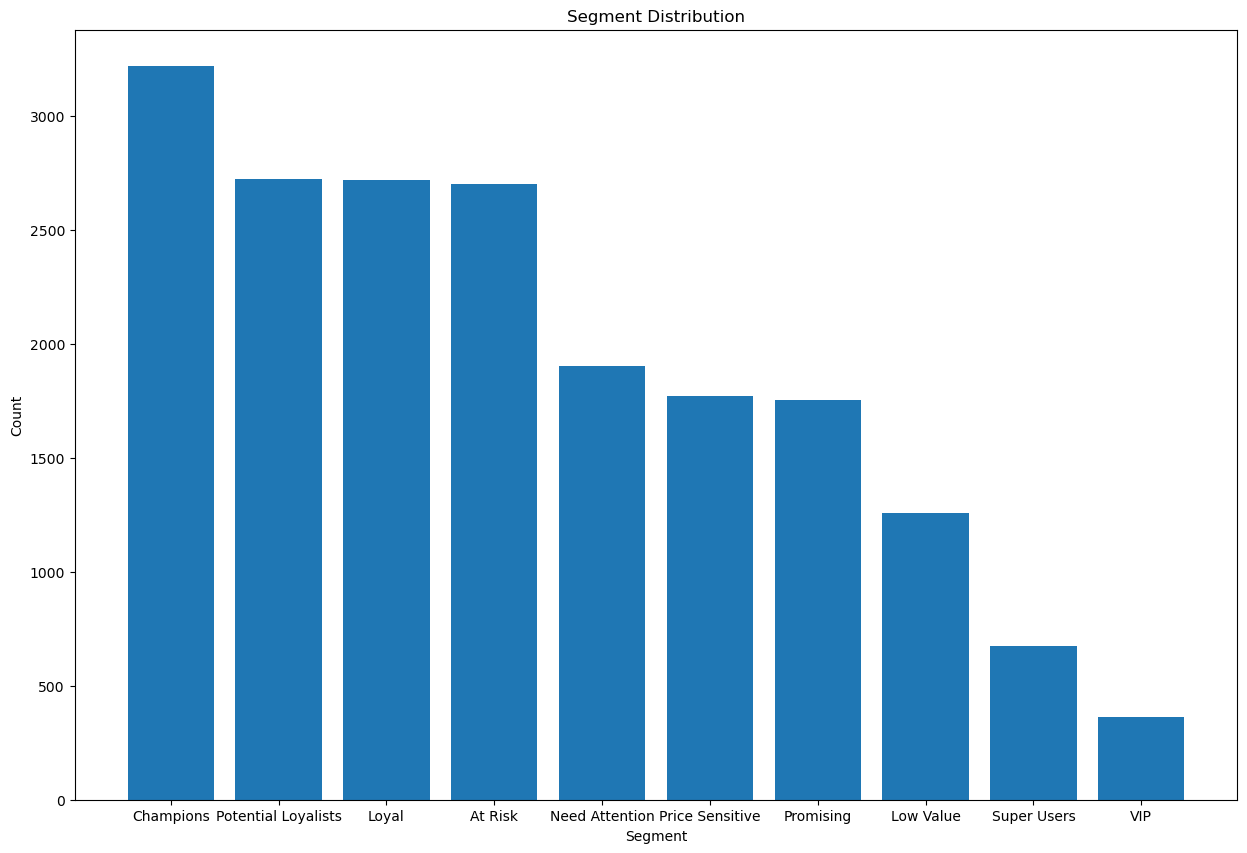

In [11]:
segment_counts = df_rfm['segment'].value_counts()

plt.figure(figsize=(15,10))
plt.bar(range(len(segment_counts)), segment_counts.values)
plt.xticks(range(len(segment_counts)), segment_counts.index)
plt.xlabel('Segment')
plt.ylabel('Count')
plt.title('Segment Distribution')
plt.show()

In [12]:
def demographic_analysis(rfm_data, n_samples=None, random_state=42):
# balanced sample selection
    segments = rfm_data['segment'].unique()
    sampled_data = []
    segment_sample_counts = {}
    
    for segment in segments:
        segment_data = rfm_data[rfm_data['segment'] == segment]
        
        if n_samples is None:
            sampled = segment_data.copy()
            actual_n = len(segment_data)
        else:
            actual_n = min(n_samples, len(segment_data))
            if len(segment_data) >= n_samples:
                sampled = segment_data.sample(n=n_samples, random_state=random_state)
            else:
                sampled = segment_data.copy()
        
        segment_sample_counts[segment] = actual_n
        sampled_data.append(sampled)
    
    df_sampled = pd.concat(sampled_data, ignore_index=True)
    
    if n_samples is None:
        print(f"\nUsing all data (total: {len(df_sampled)} customers)")
    else:
        print(f"\nSamples per segment: {n_samples}")
        print(f"Total sample size: {len(df_sampled)}")
    
# plot gender distribution by segment
    gender_segment = pd.crosstab(df_sampled['segment'], df_sampled['gender'], normalize='index')
    plt.figure(figsize=(12, 6))
    gender_segment.plot(kind='bar', stacked=True)
    plt.title('Gender Distribution by RFM Segment')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Gender')
    plt.tight_layout()
    plt.show()
    
# plot region distribution by segment
    region_segment = pd.crosstab(df_sampled['segment'], df_sampled['region_category'], normalize='index')
    plt.figure(figsize=(12, 6))
    region_segment.plot(kind='bar', stacked=True)
    plt.title('Region Distribution by RFM Segment')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
# plot membership distribution by segment
    membership_segment = pd.crosstab(df_sampled['segment'], df_sampled['membership_category'], normalize='index')
    plt.figure(figsize=(14, 6))
    membership_segment.plot(kind='bar', stacked=True)
    plt.title('Membership Distribution by RFM Segment')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
# plot churn risk by segment
    churn_segment = pd.crosstab(df_sampled['segment'], df_sampled['churn_risk_score'], normalize='index')
    churn_plot = churn_segment.copy()
    churn_plot.columns = ['No Churn', 'Churn Risk']
    plt.figure(figsize=(12, 6))
    churn_plot.plot(kind='bar', stacked=True)
    plt.title('Churn Risk by RFM Segment')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
# summarize segment demographics
    print("\nDemographic Summary:")
    
    demo_summary = df_sampled.groupby('segment').agg(
        sample_size=('age', 'count'),
        avg_age=('age', 'mean'),
        median_age=('age', 'median'),
        age_min=('age', 'min'),
        age_max=('age', 'max'),
        female_pct=('gender', lambda x: (x == 'F').mean() * 100),
        male_pct=('gender', lambda x: (x == 'M').mean() * 100),
        city_pct=('region_category', lambda x: (x == 'City').mean() * 100),
        town_pct=('region_category', lambda x: (x == 'Town').mean() * 100),
        village_pct=('region_category', lambda x: (x == 'Village').mean() * 100),
        churn_rate=('churn_risk_score', lambda x: x.mean() * 100),
        referral_pct=('joined_through_referral', lambda x: (x == 'Yes').mean() * 100),
        special_discount_pct=('used_special_discount', lambda x: (x == 'Yes').mean() * 100),
        past_complaint_pct=('past_complaint', lambda x: (x == 'Yes').mean() * 100),
        avg_points=('points_in_wallet', 'mean'),
        avg_time_spent=('avg_time_spent', 'mean'),
        desktop_pct=('medium_of_operation', lambda x: (x == 'Desktop').mean() * 100),
        smartphone_pct=('medium_of_operation', lambda x: (x == 'Smartphone').mean() * 100),
        wifi_pct=('internet_option', lambda x: (x == 'Wi-Fi').mean() * 100),
        mobile_data_pct=('internet_option', lambda x: (x == 'Mobile_Data').mean() * 100),
        fiber_pct=('internet_option', lambda x: (x == 'Fiber_Optic').mean() * 100),
        avg_recency=('Recency', 'mean'),
        avg_frequency=('Frequency', 'mean'),
        avg_monetary=('Monetary', 'mean')
    ).round(2)
   
    results = {
        'sampled_data': df_sampled,
        'demo_summary': demo_summary,
        'gender_dist': gender_segment,
        'region_dist': region_segment,
        'membership_dist': membership_segment,
        'churn_dist': churn_segment,
    }
    
    return results


Using all data (total: 19072 customers)


<Figure size 1200x600 with 0 Axes>

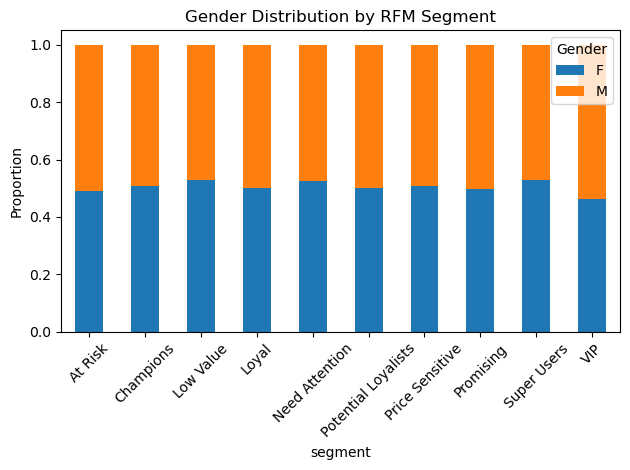

<Figure size 1200x600 with 0 Axes>

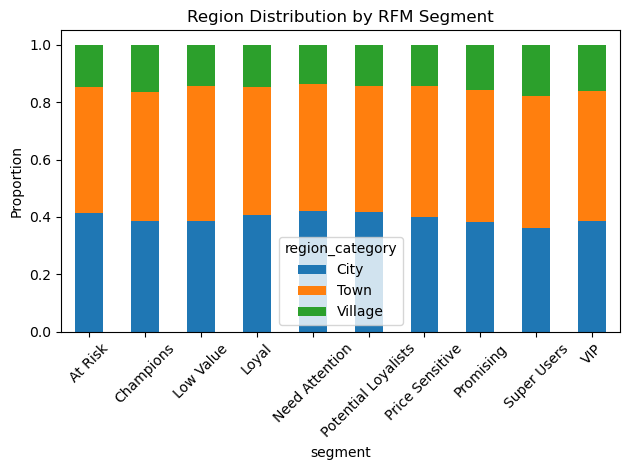

<Figure size 1400x600 with 0 Axes>

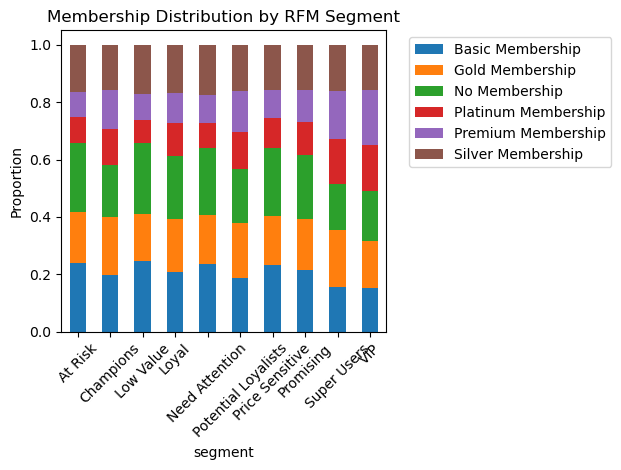

<Figure size 1200x600 with 0 Axes>

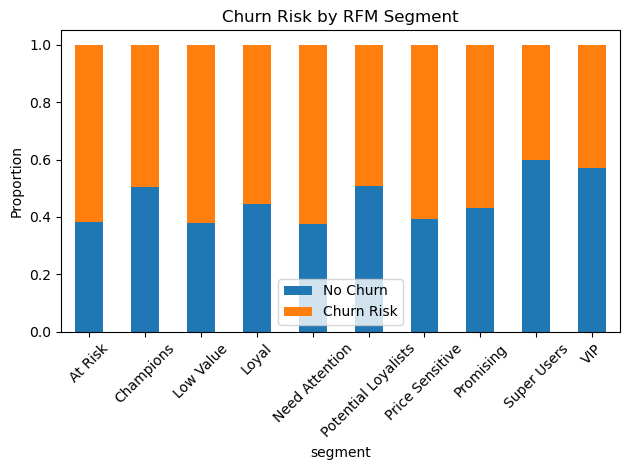


Demographic Summary:


,sample_size,avg_age,median_age,age_min,age_max,female_pct,male_pct,city_pct,town_pct,village_pct,...,avg_points,avg_time_spent,desktop_pct,smartphone_pct,wifi_pct,mobile_data_pct,fiber_pct,avg_recency,avg_frequency,avg_monetary
segment,,,,,,,,,,,,,,,,,,,,,
At Risk,2699,37.30,37.0,10,64,48.91,51.09,41.31,43.91,14.78,...,676.84,225.84,50.94,38.79,34.53,32.27,33.20,9.45,23.51,36612.48
Champions,3216,37.01,37.0,10,64,50.65,49.35,38.43,45.18,16.39,...,692.55,223.59,51.18,38.77,33.52,32.74,33.74,9.91,12.37,36972.16
Low Value,1256,37.61,38.0,10,64,52.71,47.29,38.54,47.21,14.25,...,675.29,184.18,53.18,39.57,31.85,35.19,32.96,18.65,23.35,11196.83
Loyal,2716,37.07,37.0,10,64,50.26,49.74,40.65,44.55,14.80,...,688.77,222.12,52.87,37.00,33.47,33.87,32.66,9.31,11.39,11112.69
Need Attention,1903,36.93,37.0,10,64,52.39,47.61,42.14,44.19,13.66,...,676.84,226.22,50.39,38.78,34.31,32.11,33.58,9.33,23.60,11000.31
Potential Loyalists,2723,36.98,36.0,10,64,49.98,50.02,41.72,43.74,14.54,...,695.39,191.29,53.69,38.05,33.05,33.97,32.98,18.43,11.33,38685.75
Price Sensitive,1771,36.54,36.0,10,64,50.65,49.35,39.92,45.85,14.23,...,679.48,190.63,50.88,41.16,32.13,33.65,34.22,18.55,23.69,36482.12
Promising,1754,37.10,37.0,10,64,49.89,50.11,38.37,46.01,15.62,...,683.27,185.94,54.73,37.57,33.12,31.81,35.06,18.45,11.62,11310.87
Super Users,672,38.09,39.0,10,64,52.83,47.17,36.31,45.98,17.71,...,704.32,237.81,50.60,36.76,32.74,33.33,33.93,7.40,5.93,46382.30


In [13]:
demo_results = demographic_analysis(df_rfm, n_samples=None, random_state=42)
demo_results['demo_summary']

# Clustering Analysis

## Method 1: K-Means Clustering on RFM Features

In [14]:
def label_rfm_segments(profile, cluster_col):
    p = profile.copy()
    r_med = p['Recency'].median()
    f_med = p['Frequency'].median()
    m_med = p['Monetary'].median()

    def assign(row):
        hi_m = row['Monetary'] >= m_med
        lo_r = row['Recency']  <= r_med   # low recency = visited recently
        hi_f = row['Frequency'] >= f_med
        if hi_m and lo_r and hi_f:
            return 'Champions'
        elif hi_m and lo_r:
            return 'Potential Loyalists'
        elif hi_m and not lo_r:
            return 'High-Value At-Risk'
        elif lo_r and hi_f:
            return 'Loyal Actives'
        elif lo_r and not hi_f:
            return 'Engaged Casuals'
        elif not lo_r and hi_f:
            return 'Slipping Regulars'
        else:
            return 'At-Risk / Lost'

    p['Segment'] = p.apply(assign, axis=1)
    return p[['Recency', 'Frequency', 'Monetary', 'Segment']]


def kmeans_rfm(rfm_data, n_clusters=4, random_state=42):
    assert n_clusters >= 3, 'n_clusters must be at least 3'
    data = rfm_data.copy()
    cluster_features = data[['Recency', 'Frequency', 'Monetary']].copy()

    scaler = StandardScaler()
    X_rfm = scaler.fit_transform(cluster_features)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    data['kmeans_rfm_cluster'] = km.fit_predict(X_rfm)
    sil = silhouette_score(X_rfm, data['kmeans_rfm_cluster'])

    profile = data.groupby('kmeans_rfm_cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
    named_profile = label_rfm_segments(profile, 'kmeans_rfm_cluster')
    cluster_to_name = named_profile['Segment'].to_dict()
    data['kmeans_rfm_segment'] = data['kmeans_rfm_cluster'].map(cluster_to_name)

    print(f'K-Means RFM  |  k={n_clusters}  |  Silhouette: {sil:.4f}')
    print()
    for c, row in named_profile.iterrows():
        cnt = (data['kmeans_rfm_cluster'] == c).sum()
        print(f"  Cluster {c} → '{row['Segment']}': {cnt} customers ({cnt/len(data)*100:.1f}%)")
        print(f"    Recency={row['Recency']:.1f}d  Frequency={row['Frequency']:.1f}  Monetary=${row['Monetary']:,.0f}")

# visualize clusters with PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_rfm)
    palette = dict(zip(named_profile['Segment'].unique(),
                       plt.cm.tab10.colors[:len(named_profile)]))
    plt.figure(figsize=(9, 6))
    for seg, grp in data.groupby('kmeans_rfm_segment'):
        idx = grp.index
        plt.scatter(X_pca[data.index.get_indexer(idx), 0],
                    X_pca[data.index.get_indexer(idx), 1],
                    label=seg, alpha=0.5, s=20)
    plt.title(f'K-Means RFM Segments (k={n_clusters}, sil={sil:.3f})')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# compare distributions by segment
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
        sns.boxplot(data=data, x='kmeans_rfm_segment', y=col, ax=ax, showfliers=False)
        ax.set_title(col); ax.set_xlabel('Segment')
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle(f'K-Means RFM Segments (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

# show segment counts
    seg_counts = data['kmeans_rfm_segment'].value_counts()
    plt.figure(figsize=(9, 4))
    bars = plt.bar(seg_counts.index, seg_counts.values)
    for bar, val in zip(bars, seg_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
    plt.title('K-Means RFM — Segment Distribution'); plt.ylabel('Customers')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

    print('\nNamed Segment Profiles:')
    print(named_profile.to_string())

    return {'model': km, 'scaler': scaler, 'silhouette': sil,
            'data_with_clusters': data, 'profile': named_profile}


K-Means RFM  |  k=4  |  Silhouette: 0.2451

  Cluster 0 → 'Engaged Casuals': 4720 customers (24.7%)
    Recency=8.3d  Frequency=13.0  Monetary=$15,892
  Cluster 1 → 'Potential Loyalists': 4438 customers (23.3%)
    Recency=11.6d  Frequency=11.9  Monetary=$46,498
  Cluster 2 → 'Slipping Regulars': 4797 customers (25.2%)
    Recency=18.9d  Frequency=13.8  Monetary=$21,148
  Cluster 3 → 'High-Value At-Risk': 5117 customers (26.8%)
    Recency=12.8d  Frequency=25.3  Monetary=$26,879


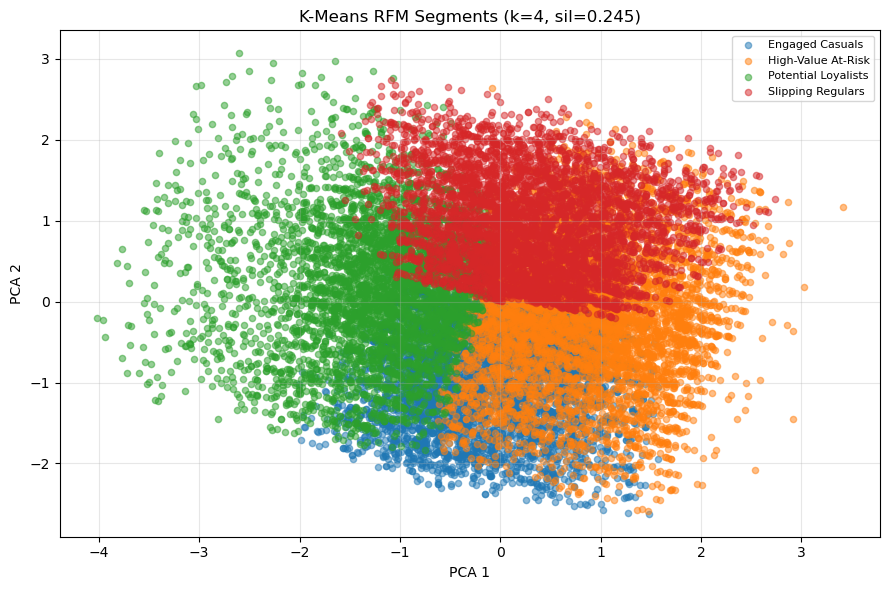

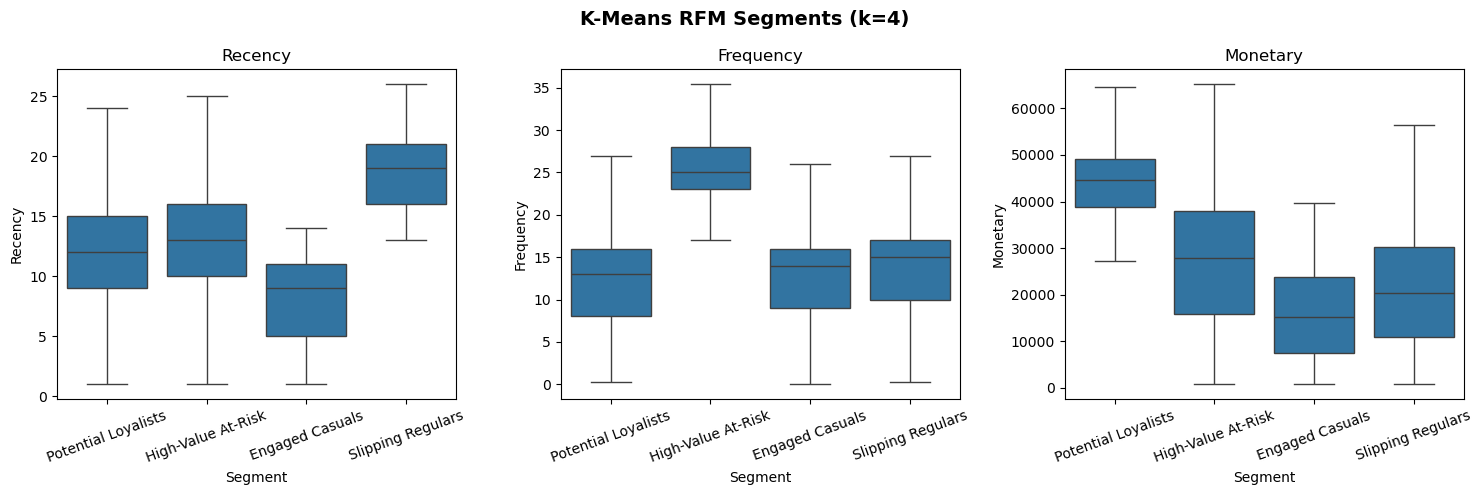

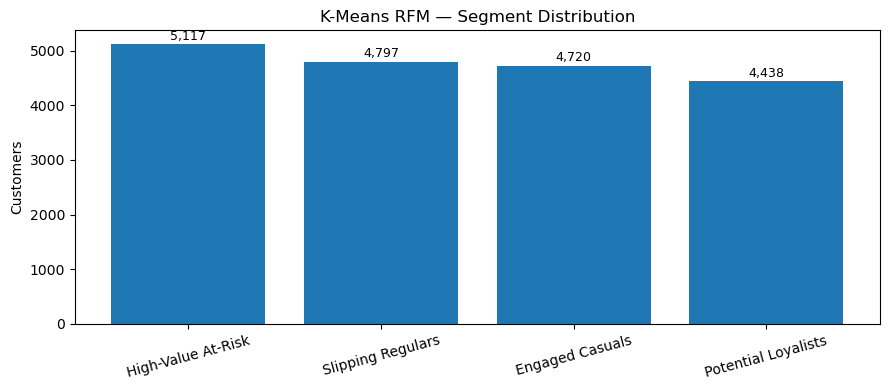


Named Segment Profiles:
                    Recency  Frequency  Monetary              Segment
kmeans_rfm_cluster                                                   
0                      8.27      13.03  15891.76      Engaged Casuals
1                     11.56      11.89  46497.75  Potential Loyalists
2                     18.87      13.81  21148.04    Slipping Regulars
3                     12.77      25.29  26878.66   High-Value At-Risk


In [15]:
km_rfm_results = kmeans_rfm(df_rfm, n_clusters=4, random_state=42)
df_rfm_clustered = km_rfm_results['data_with_clusters']


## Method 2: Hierarchical (Agglomerative) Clustering on RFM Features

In [16]:
def hierarchical_rfm(rfm_data, n_clusters=4, random_state=42):
    assert n_clusters >= 3, 'n_clusters must be at least 3'
    data = rfm_data.copy()
    cluster_features = data[['Recency', 'Frequency', 'Monetary']].copy()

    scaler = StandardScaler()
    X_rfm = scaler.fit_transform(cluster_features)

# draw sample dendrogram for Ward clustering
    sample_size = min(2000, len(X_rfm))
    sample_idx = np.random.default_rng(random_state).choice(len(X_rfm), size=sample_size, replace=False)
    Z = linkage(X_rfm[sample_idx], method='ward')
    plt.figure(figsize=(14, 5))
    dendrogram(Z, truncate_mode='lastp', p=30, color_threshold=0.7 * max(Z[:, 2]))
    plt.title(f'Dendrogram — RFM  (Ward linkage, sample={sample_size})')
    plt.xlabel('Cluster size'); plt.ylabel('Distance')
    plt.tight_layout(); plt.show()

    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    data['hier_rfm_cluster'] = agg.fit_predict(X_rfm)
    sil = silhouette_score(X_rfm, data['hier_rfm_cluster'])

    profile = data.groupby('hier_rfm_cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
    named_profile = label_rfm_segments(profile, 'hier_rfm_cluster')
    cluster_to_name = named_profile['Segment'].to_dict()
    data['hier_rfm_segment'] = data['hier_rfm_cluster'].map(cluster_to_name)

    print(f'Hierarchical RFM  |  k={n_clusters}  |  Silhouette: {sil:.4f}')
    print()
    for c, row in named_profile.iterrows():
        cnt = (data['hier_rfm_cluster'] == c).sum()
        print(f"  Cluster {c} → '{row['Segment']}': {cnt} customers ({cnt/len(data)*100:.1f}%)")
        print(f"    Recency={row['Recency']:.1f}d  Frequency={row['Frequency']:.1f}  Monetary=${row['Monetary']:,.0f}")

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_rfm)
    plt.figure(figsize=(9, 6))
    for seg, grp in data.groupby('hier_rfm_segment'):
        idx = grp.index
        plt.scatter(X_pca[data.index.get_indexer(idx), 0],
                    X_pca[data.index.get_indexer(idx), 1],
                    label=seg, alpha=0.5, s=20)
    plt.title(f'Hierarchical RFM Segments (k={n_clusters}, sil={sil:.3f})')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# compare distributions by segment
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
        sns.boxplot(data=data, x='hier_rfm_segment', y=col, ax=ax, showfliers=False)
        ax.set_title(col); ax.set_xlabel('Segment')
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle(f'Hierarchical RFM Segments (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

# show segment counts
    seg_counts = data['hier_rfm_segment'].value_counts()
    plt.figure(figsize=(9, 4))
    bars = plt.bar(seg_counts.index, seg_counts.values)
    for bar, val in zip(bars, seg_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
    plt.title('Hierarchical RFM — Segment Distribution'); plt.ylabel('Customers')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

# compare segment agreement
    if 'kmeans_rfm_segment' in data.columns:
        agreement = pd.crosstab(
            data['kmeans_rfm_segment'], data['hier_rfm_segment'],
            rownames=['K-Means'], colnames=['Hierarchical']
        )
        plt.figure(figsize=(8, 6))
        sns.heatmap(agreement, annot=True, fmt='d')
        plt.title('RFM: K-Means vs Hierarchical Segment Agreement')
        plt.tight_layout(); plt.show()

    print('\nNamed Segment Profiles:')
    print(named_profile.to_string())

    return {'model': agg, 'scaler': scaler, 'silhouette': sil,
            'data_with_clusters': data, 'profile': named_profile}


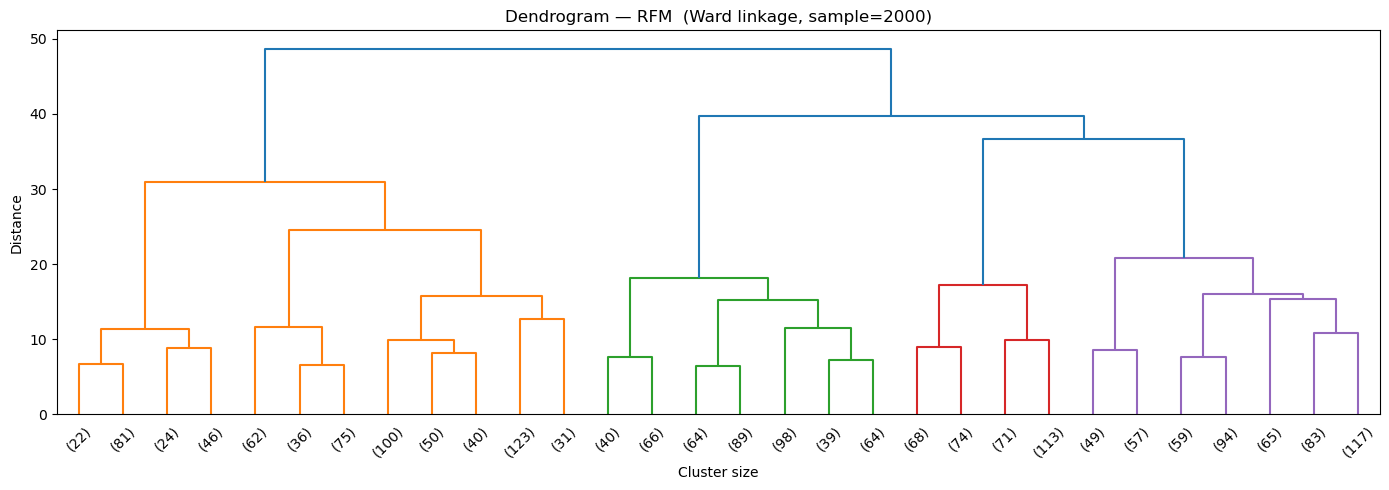

Hierarchical RFM  |  k=4  |  Silhouette: 0.1950

  Cluster 0 → 'Loyal Actives': 4550 customers (23.9%)
    Recency=14.5d  Frequency=25.3  Monetary=$25,416
  Cluster 1 → 'Champions': 5546 customers (29.1%)
    Recency=7.3d  Frequency=14.6  Monetary=$30,689
  Cluster 2 → 'High-Value At-Risk': 4100 customers (21.5%)
    Recency=16.3d  Frequency=11.1  Monetary=$42,237
  Cluster 3 → 'At-Risk / Lost': 4876 customers (25.6%)
    Recency=15.0d  Frequency=14.0  Monetary=$12,579


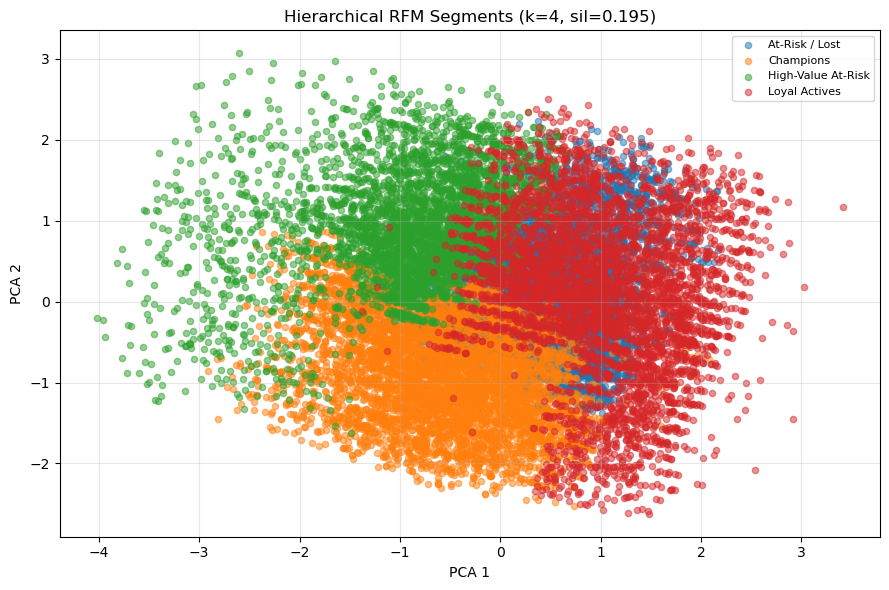

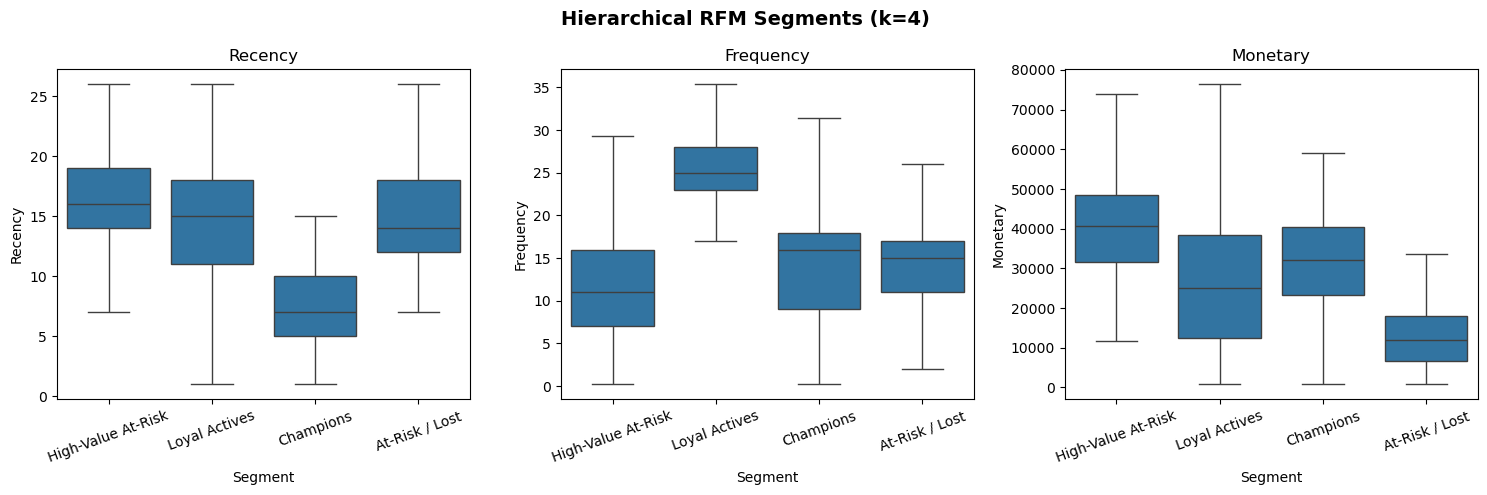

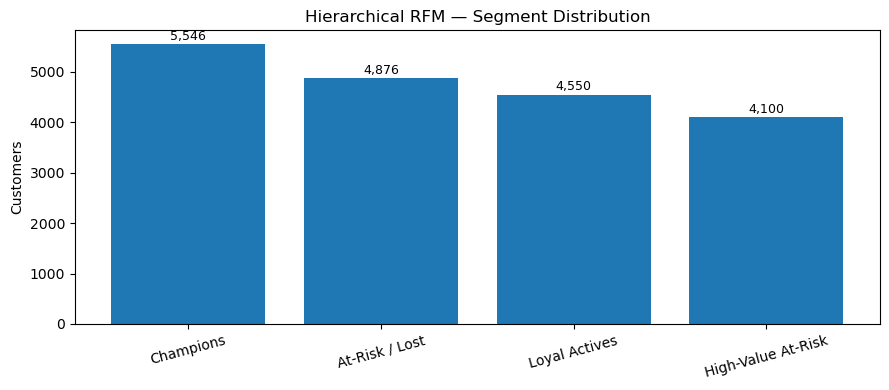


Named Segment Profiles:
                  Recency  Frequency  Monetary             Segment
hier_rfm_cluster                                                  
0                   14.47      25.26  25416.18       Loyal Actives
1                    7.29      14.58  30688.80           Champions
2                   16.30      11.13  42236.84  High-Value At-Risk
3                   14.99      14.04  12579.29      At-Risk / Lost


In [17]:
hier_rfm_results = hierarchical_rfm(df_rfm, n_clusters=4, random_state=42)
df_rfm_hier = hier_rfm_results['data_with_clusters']


## Method 3: K-Means Clustering on Behavioral & Demographic Features

In [29]:
def encode_and_scale(dataframe, cat_cols, num_cols):
    df_proc = dataframe[cat_cols + num_cols].copy()

    ordinal_maps = {
        'membership_category': {
            'No Membership': 0, 'Basic Membership': 1,
            'Silver Membership': 2, 'Gold Membership': 3,
            'Platinum Membership': 4, 'Premium Membership': 5
        },
        'feedback': {
            'Poor': 0, 'Below Average': 1, 'Average': 2,
            'Good': 3, 'Excellent': 4
        },
        'complaint_status': {
            'No Information Available': 0, 'Unsolved': 1,
            'Solved in Follow-up': 2, 'Solved': 3
        },
    }
    for col, mapping in ordinal_maps.items():
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].map(mapping).fillna(0).astype(int)

    binary_cols = [
        'gender', 'used_special_discount', 'offer_application_preference',
        'past_complaint', 'joined_through_referral'
    ]
    binary_maps = {
        'gender':                        {'M': 0, 'F': 1},
        'used_special_discount':         {'No': 0, 'Yes': 1},
        'offer_application_preference':  {'No': 0, 'Yes': 1},
        'past_complaint':                {'No': 0, 'Yes': 1},
        'joined_through_referral':       {'No': 0, 'Yes': 1},
    }
    for col, mapping in binary_maps.items():
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].map(mapping).fillna(0).astype(int)

    nominal_cols = ['region_category', 'preferred_offer_types',
                    'medium_of_operation', 'internet_option']
    nominal_present = [c for c in nominal_cols if c in df_proc.columns]
    df_proc = pd.get_dummies(df_proc, columns=nominal_present, drop_first=False)


    scaler = StandardScaler()
    df_proc = pd.DataFrame(
        scaler.fit_transform(df_proc),
        columns=df_proc.columns,
        index=df_proc.index
    )
    return df_proc
    
categorical_cols = [
    'gender', 'region_category', 'membership_category',
    'preferred_offer_types', 'medium_of_operation', 'internet_option',
    'used_special_discount', 'offer_application_preference',
    'past_complaint', 'complaint_status', 'feedback', 'joined_through_referral'
]

numeric_cols = [
    'age', 'avg_time_spent', 'avg_transaction_value',
    'avg_frequency_login_days', 'days_since_last_login', 'points_in_wallet'
]
df_proc = encode_and_scale(df_no_outliers, categorical_cols, numeric_cols)
X_behav = df_proc.values
print('Feature matrix shape:', X_behav.shape)
# Shape will expand from (N, 18) to roughly (N, 45-50) depending on category cardinality

Feature matrix shape: (19072, 26)


### Elbow & Silhouette — Find Best k (Behavioral)

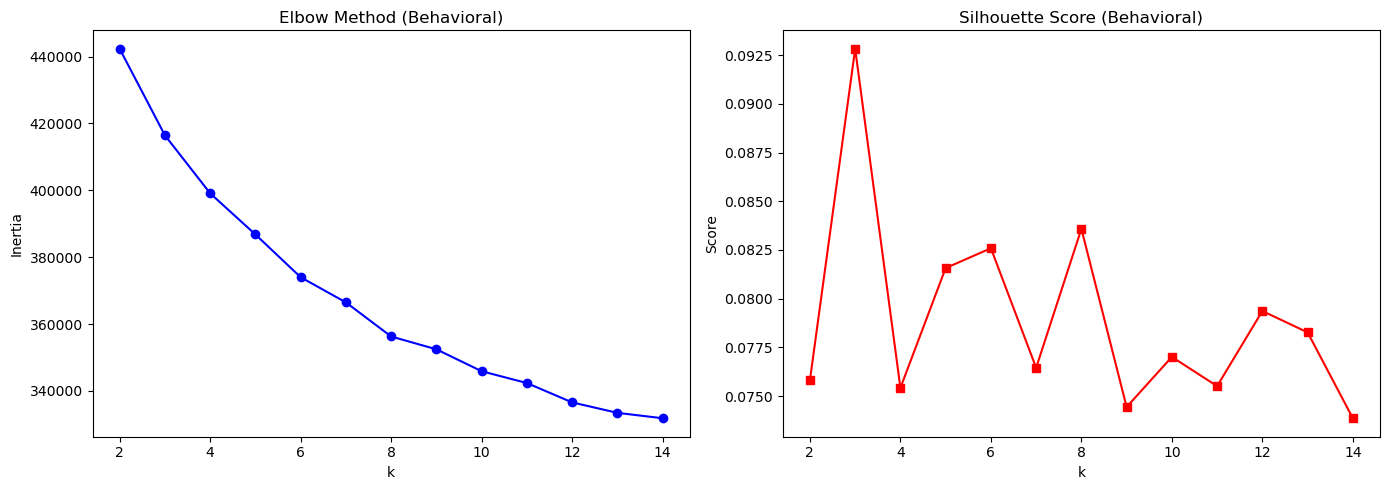

Best k (behavioral): 3


In [30]:
inertias, sil_scores, k_range = [], [], range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_behav)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_behav, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set(title='Elbow Method (Behavioral)', xlabel='k', ylabel='Inertia')
axes[1].plot(list(k_range), sil_scores, 'rs-')
axes[1].set(title='Silhouette Score (Behavioral)', xlabel='k', ylabel='Score')
plt.tight_layout(); plt.show()

best_k_behav = list(k_range)[sil_scores.index(max(sil_scores))]
best_k_behav = max(best_k_behav, 3)  # enforce minimum 3 clusters
print(f'Best k (behavioral): {best_k_behav}')


In [31]:
def label_behavioral_segments(profile, num_cols):
    p = profile.copy()

    key_cols = ['avg_time_spent', 'avg_transaction_value',
                'avg_frequency_login_days', 'days_since_last_login', 'points_in_wallet']
    key_cols = [c for c in key_cols if c in p.columns]

    medians = p[key_cols].median()

    def assign(row):
        hi_spend  = row.get('avg_transaction_value', medians.get('avg_transaction_value', 0)) >= medians.get('avg_transaction_value', 0)
        hi_time   = row.get('avg_time_spent', medians.get('avg_time_spent', 0))        >= medians.get('avg_time_spent', 0)
        hi_freq   = row.get('avg_frequency_login_days', medians.get('avg_frequency_login_days', 0)) >= medians.get('avg_frequency_login_days', 0)
        lo_since  = row.get('days_since_last_login', medians.get('days_since_last_login', 999))  <= medians.get('days_since_last_login', 999)
        hi_points = row.get('points_in_wallet', medians.get('points_in_wallet', 0))    >= medians.get('points_in_wallet', 0)

        if hi_spend and hi_time and hi_freq and lo_since:
            return 'Power Users'
        elif hi_spend and lo_since and hi_points:
            return 'High-Value Loyalists'
        elif hi_spend and not lo_since:
            return 'High-Value Churners'
        elif hi_freq and hi_time and not hi_spend:
            return 'Active Bargain Hunters'
        elif lo_since and not hi_freq and not hi_spend:
            return 'New / Occasional'
        elif not lo_since and hi_freq:
            return 'Slipping Regulars'
        else:
            return 'Passive / At-Risk'

    p['Segment'] = p[key_cols].apply(assign, axis=1)
    return p


In [32]:
def kmeans_behavioral(dataframe, X, num_cols, n_clusters=None, random_state=42):
    if n_clusters is None:
        n_clusters = best_k_behav
    n_clusters = max(n_clusters, 3)

    data = dataframe.copy()
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    data['kmeans_behav_cluster'] = km.fit_predict(X)
    sil = silhouette_score(X, data['kmeans_behav_cluster'], sample_size=5000, random_state=random_state)

    profile = data.groupby('kmeans_behav_cluster')[num_cols].mean().round(2)
    named_profile = label_behavioral_segments(profile, num_cols)
    cluster_to_name = named_profile['Segment'].to_dict()
    data['kmeans_behav_segment'] = data['kmeans_behav_cluster'].map(cluster_to_name)

    print(f'K-Means Behavioral  |  k={n_clusters}  |  Silhouette: {sil:.4f}')
    print()
    for c, row in named_profile.iterrows():
        cnt = (data['kmeans_behav_cluster'] == c).sum()
        print(f"  Cluster {c} → '{row['Segment']}': {cnt} customers ({cnt/len(data)*100:.1f}%)")

# compare distributions by segment
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=data, x='kmeans_behav_segment', y=col, ax=ax, showfliers=False)
        ax.set_title(col); ax.set_xlabel('Segment')
        ax.tick_params(axis='x', rotation=25)
    plt.suptitle(f'K-Means Behavioral Segments (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(9, 6))
    for seg, grp in data.groupby('kmeans_behav_segment'):
        idx = grp.index
        plt.scatter(X_pca[data.index.get_indexer(idx), 0],
                    X_pca[data.index.get_indexer(idx), 1],
                    label=seg, alpha=0.5, s=20)
    plt.title(f'K-Means Behavioral Segments (k={n_clusters}, sil={sil:.3f})')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# show segment counts
    seg_counts = data['kmeans_behav_segment'].value_counts()
    plt.figure(figsize=(9, 4))
    bars = plt.bar(seg_counts.index, seg_counts.values)
    for bar, val in zip(bars, seg_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
    plt.title('K-Means Behavioral — Segment Distribution'); plt.ylabel('Customers')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

    print('\nNamed Segment Profiles:')
    print(named_profile[['Segment'] + [c for c in num_cols if c in named_profile.columns]].to_string())

    return {'model': km, 'silhouette': sil,
            'data_with_clusters': data, 'profile': named_profile}


K-Means Behavioral  |  k=3  |  Silhouette: 0.0928

  Cluster 0 → 'Power Users': 1810 customers (9.5%)
  Cluster 1 → 'Power Users': 9929 customers (52.1%)
  Cluster 2 → 'Slipping Regulars': 7333 customers (38.4%)


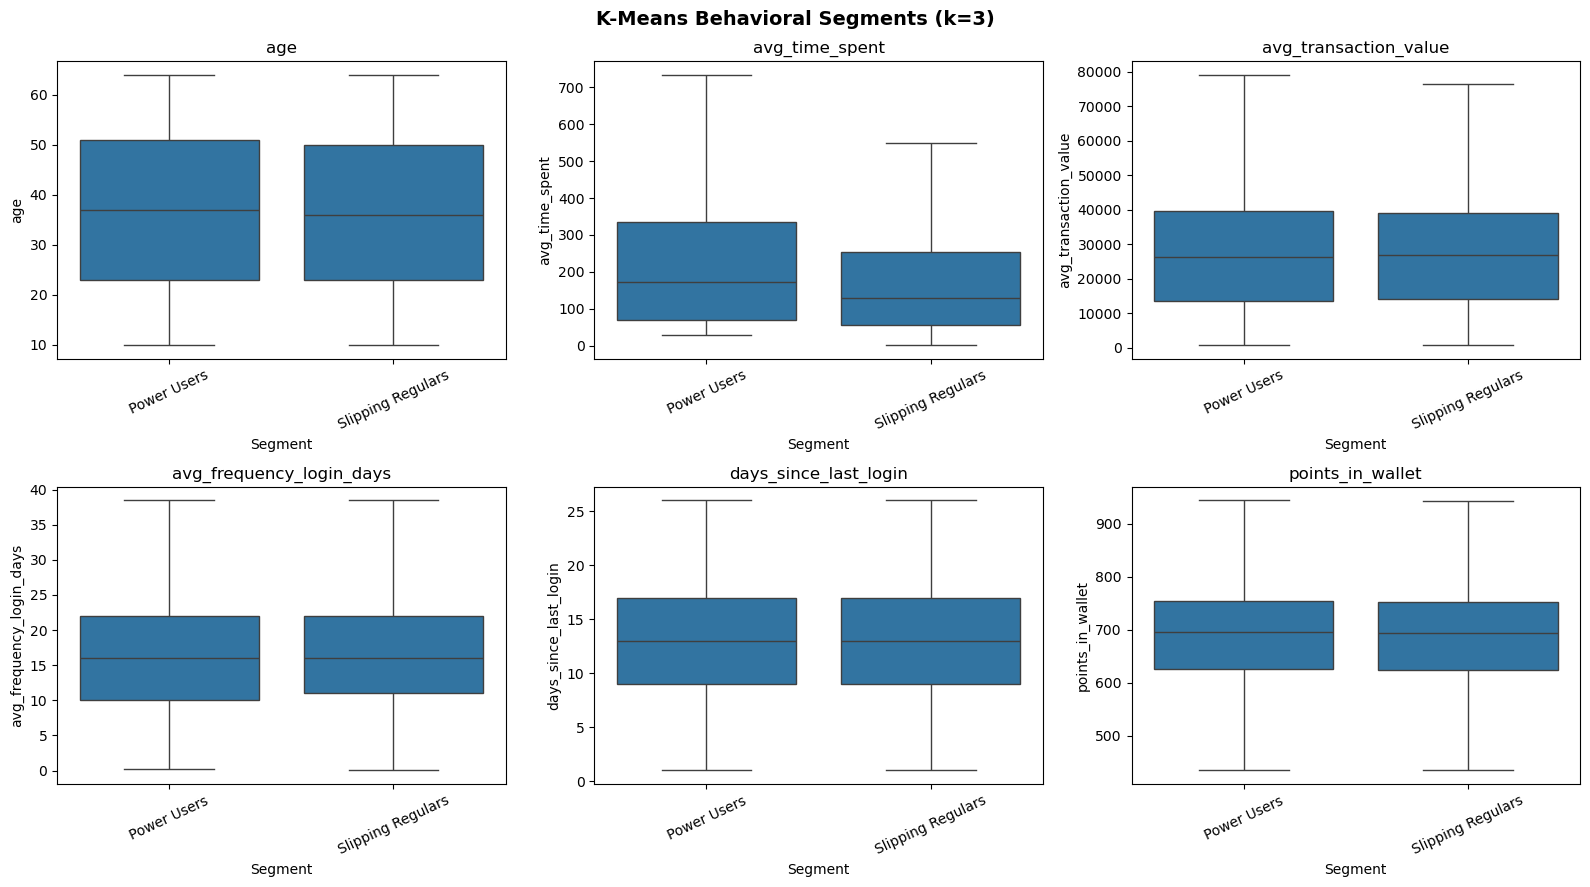

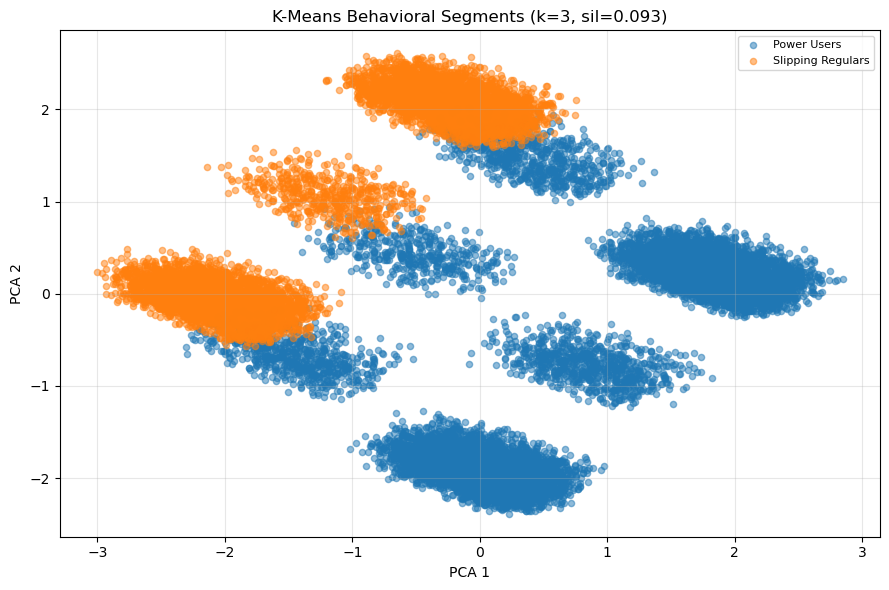

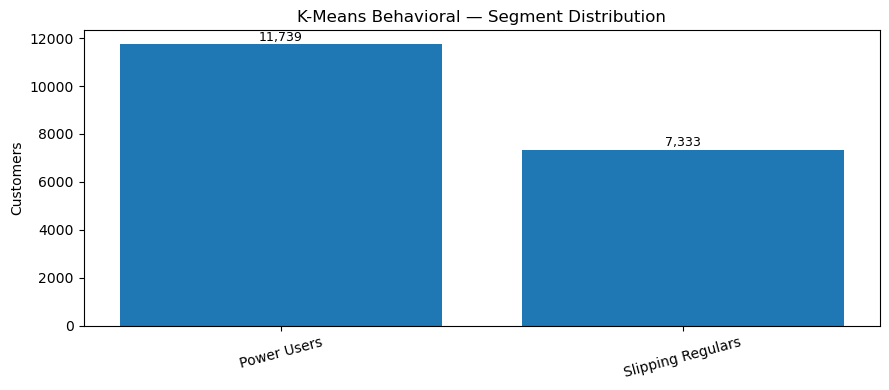


Named Segment Profiles:
                                Segment    age  avg_time_spent  avg_transaction_value  avg_frequency_login_days  days_since_last_login  points_in_wallet
kmeans_behav_cluster                                                                                                                                    
0                           Power Users  36.66          431.91               27990.74                     16.15                  11.99            686.43
1                           Power Users  37.40          191.64               27229.87                     16.15                  12.99            686.44
2                     Slipping Regulars  36.78          183.82               27181.61                     16.42                  13.03            685.41


In [33]:
km_behav_results = kmeans_behavioral(df_no_outliers, X_behav, numeric_cols, n_clusters=None, random_state=42)
df_behav_clustered = km_behav_results['data_with_clusters']


## Method 4: Hierarchical (Agglomerative) Clustering on Behavioral & Demographic Features

In [34]:
def hierarchical_behavioral(dataframe, X, num_cols, n_clusters=None, random_state=42):
    if n_clusters is None:
        n_clusters = best_k_behav
    n_clusters = max(n_clusters, 3)

    data = dataframe.copy()

# draw sample dendrogram for Ward clustering
    sample_size = min(3000, len(X))
    sample_idx = np.random.default_rng(random_state).choice(len(X), size=sample_size, replace=False)
    Z = linkage(X[sample_idx], method='ward')
    plt.figure(figsize=(16, 6))
    dendrogram(Z, truncate_mode='lastp', p=30, color_threshold=0.7 * max(Z[:, 2]))
    plt.title(f'Dendrogram — Behavioral & Demographics (Ward, sample={sample_size})')
    plt.xlabel('Cluster size'); plt.ylabel('Distance')
    plt.tight_layout(); plt.show()

    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    data['hier_behav_cluster'] = agg.fit_predict(X)
    sil = silhouette_score(X, data['hier_behav_cluster'], sample_size=5000, random_state=random_state)

    profile = data.groupby('hier_behav_cluster')[num_cols].mean().round(2)
    named_profile = label_behavioral_segments(profile, num_cols)
    cluster_to_name = named_profile['Segment'].to_dict()
    data['hier_behav_segment'] = data['hier_behav_cluster'].map(cluster_to_name)

    print(f'Hierarchical Behavioral  |  k={n_clusters}  |  Silhouette: {sil:.4f}')
    print()
    for c, row in named_profile.iterrows():
        cnt = (data['hier_behav_cluster'] == c).sum()
        print(f"  Cluster {c} → '{row['Segment']}': {cnt} customers ({cnt/len(data)*100:.1f}%)")

# compare distributions by segment
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=data, x='hier_behav_segment', y=col, ax=ax, showfliers=False)
        ax.set_title(col); ax.set_xlabel('Segment')
        ax.tick_params(axis='x', rotation=25)
    plt.suptitle(f'Hierarchical Behavioral Segments (k={n_clusters})', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(9, 6))
    for seg, grp in data.groupby('hier_behav_segment'):
        idx = grp.index
        plt.scatter(X_pca[data.index.get_indexer(idx), 0],
                    X_pca[data.index.get_indexer(idx), 1],
                    label=seg, alpha=0.5, s=20)
    plt.title(f'Hierarchical Behavioral Segments (k={n_clusters}, sil={sil:.3f})')
    plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# show segment counts
    seg_counts = data['hier_behav_segment'].value_counts()
    plt.figure(figsize=(9, 4))
    bars = plt.bar(seg_counts.index, seg_counts.values)
    for bar, val in zip(bars, seg_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
    plt.title('Hierarchical Behavioral — Segment Distribution'); plt.ylabel('Customers')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

    if 'kmeans_behav_segment' in data.columns:
        agreement = pd.crosstab(
            data['kmeans_behav_segment'], data['hier_behav_segment'],
            rownames=['K-Means'], colnames=['Hierarchical']
        )
        plt.figure(figsize=(9, 7))
        sns.heatmap(agreement, annot=True, fmt='d')
        plt.title('Behavioral: K-Means vs Hierarchical Segment Agreement')
        plt.tight_layout(); plt.show()

    print('\nNamed Segment Profiles:')
    print(named_profile[['Segment'] + [c for c in num_cols if c in named_profile.columns]].to_string())

    return {'model': agg, 'silhouette': sil,
            'data_with_clusters': data, 'profile': named_profile}


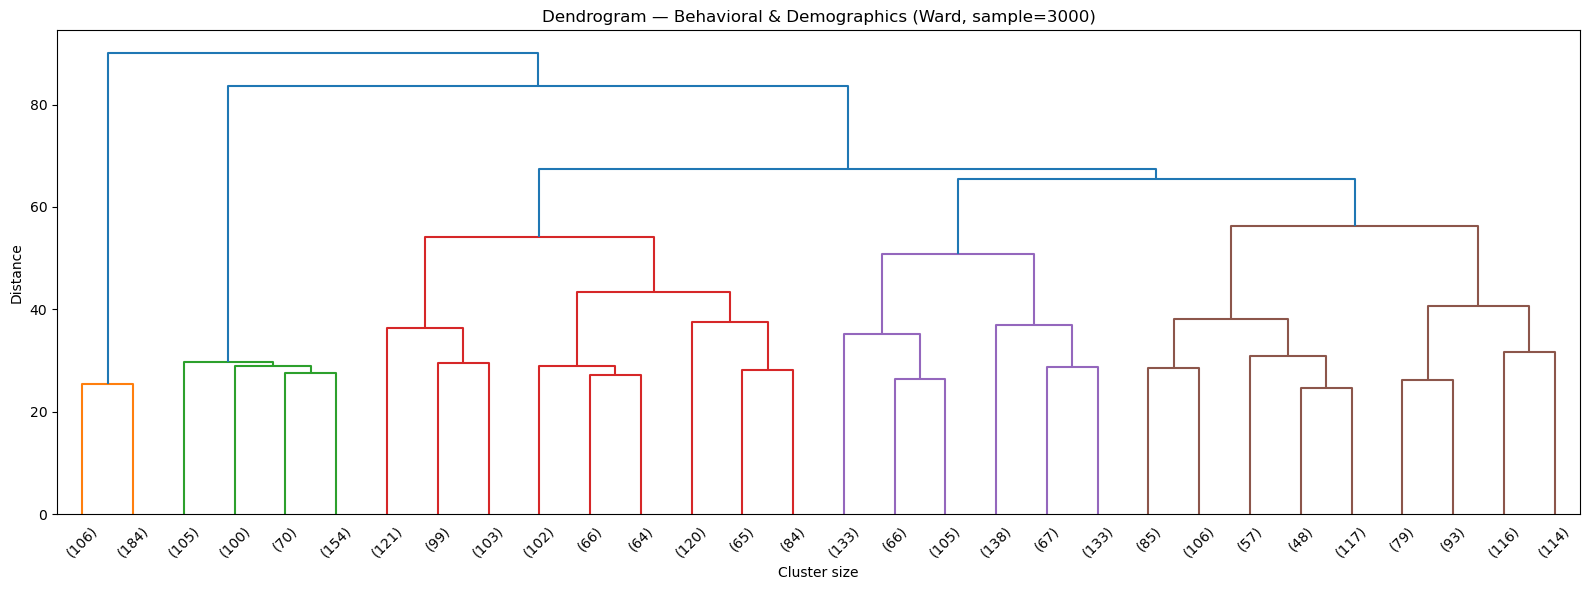

Hierarchical Behavioral  |  k=3  |  Silhouette: 0.0655

  Cluster 0 → 'Passive / At-Risk': 11899 customers (62.4%)
  Cluster 1 → 'Power Users': 1810 customers (9.5%)
  Cluster 2 → 'Slipping Regulars': 5363 customers (28.1%)


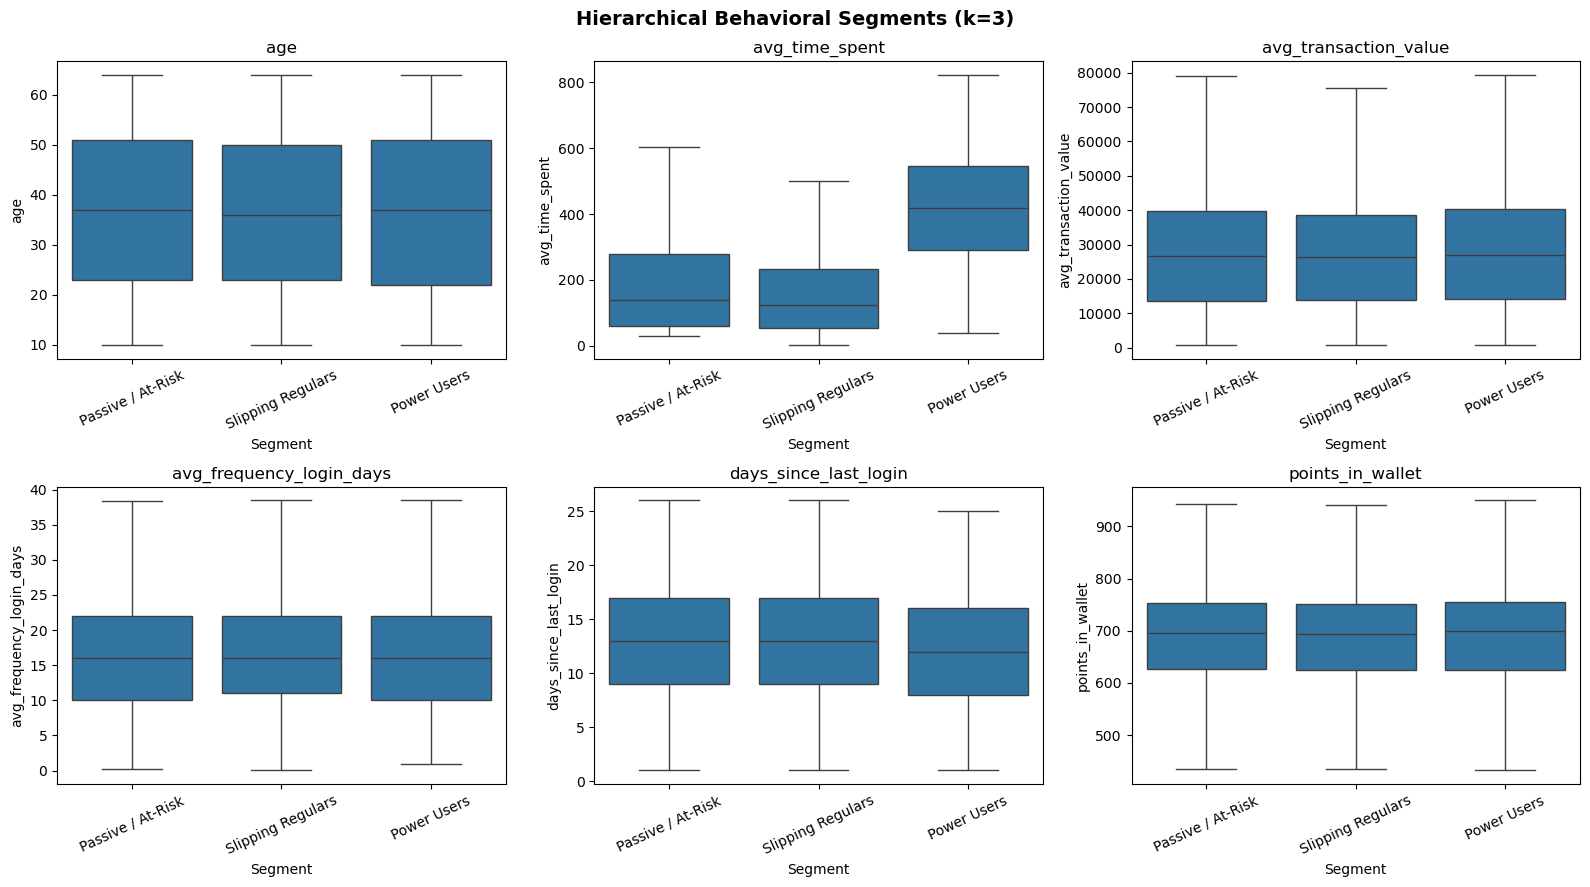

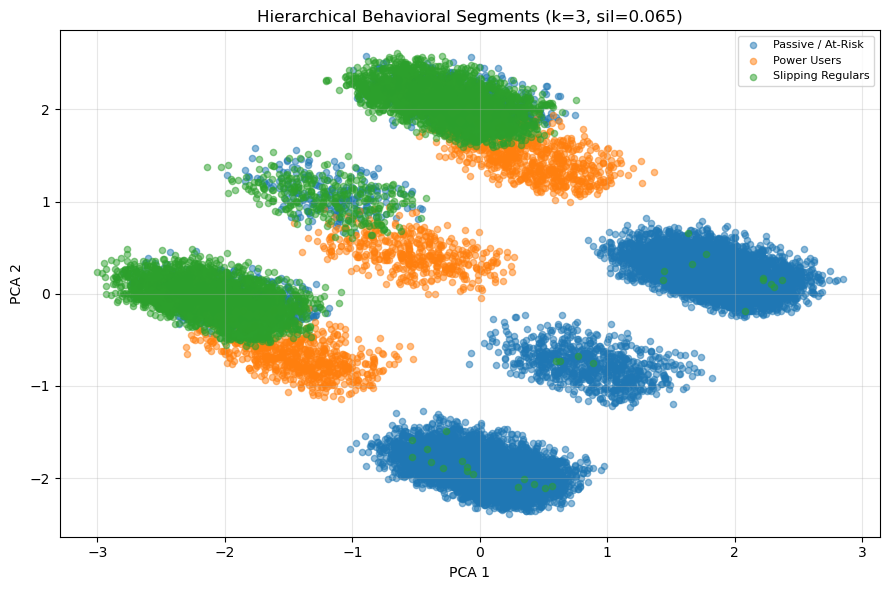

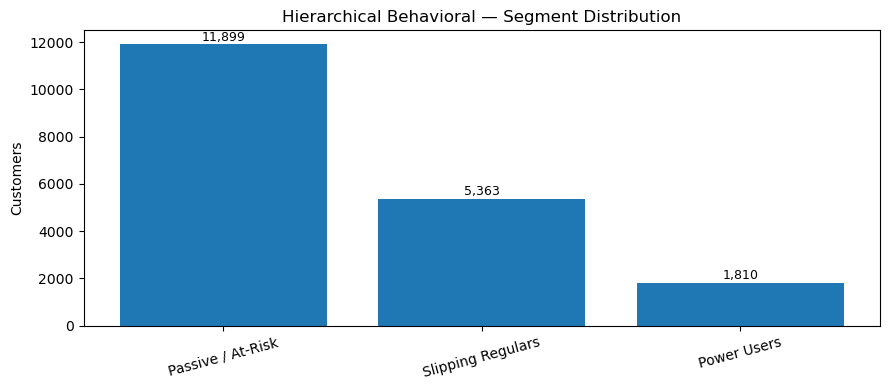

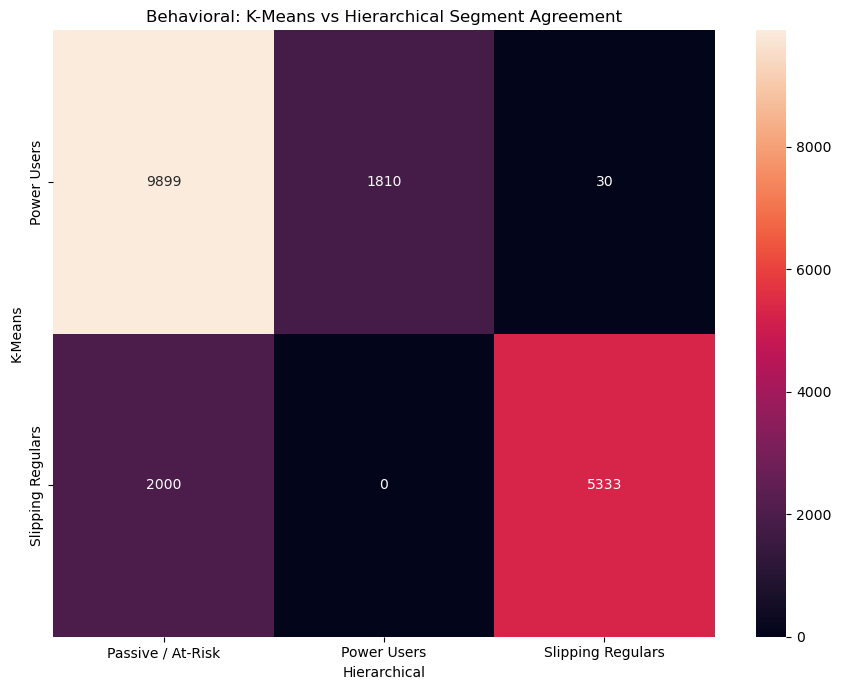


Named Segment Profiles:
                              Segment    age  avg_time_spent  avg_transaction_value  avg_frequency_login_days  days_since_last_login  points_in_wallet
hier_behav_cluster                                                                                                                                    
0                   Passive / At-Risk  37.27          197.70               27466.59                     16.14                  12.95            685.92
1                         Power Users  36.66          431.91               27990.74                     16.15                  11.99            686.43
2                   Slipping Regulars  36.84          167.51               26638.66                     16.53                  13.13            686.18


In [35]:
# Pass the dataframe that already has kmeans_behav_cluster for the agreement heatmap
hier_behav_results = hierarchical_behavioral(df_behav_clustered, X_behav, numeric_cols, n_clusters=None, random_state=42)
df_behav_hier = hier_behav_results['data_with_clusters']


## Summary: Silhouette Score Comparison Across All 4 Methods

Clustering Method Comparison:
                                  Method  Silhouette Score
                           K-Means (RFM)            0.2451
                      Hierarchical (RFM)            0.1950
     K-Means (Behavioral & Demographics)            0.0928
Hierarchical (Behavioral & Demographics)            0.0655


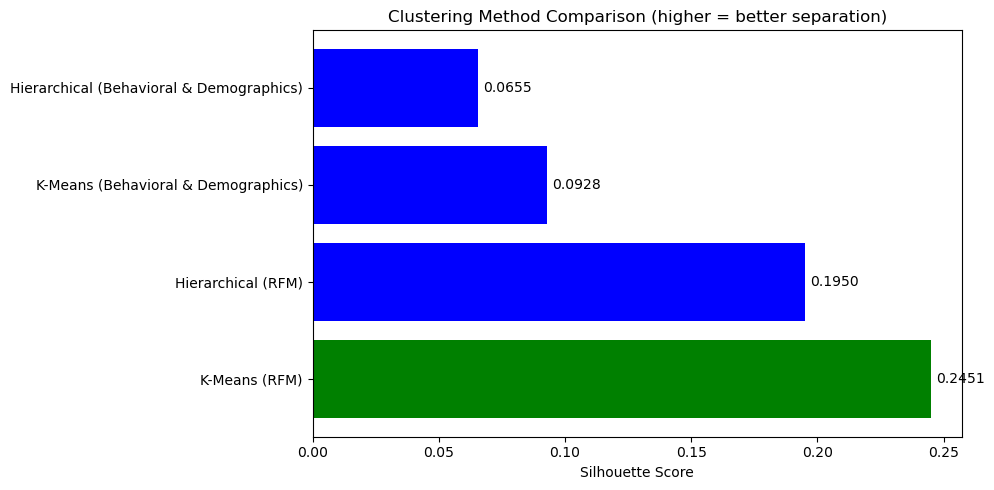

In [36]:
summary = pd.DataFrame({
    'Method': [
        'K-Means (RFM)',
        'Hierarchical (RFM)',
        'K-Means (Behavioral & Demographics)',
        'Hierarchical (Behavioral & Demographics)'
    ],
    'Silhouette Score': [
        km_rfm_results['silhouette'],
        hier_rfm_results['silhouette'],
        km_behav_results['silhouette'],
        hier_behav_results['silhouette']
    ]
})
summary['Silhouette Score'] = summary['Silhouette Score'].round(4)
summary = summary.sort_values('Silhouette Score', ascending=False).reset_index(drop=True)
print('Clustering Method Comparison:')
print(summary.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['green' if i == 0 else 'blue' for i in range(len(summary))]
bars = plt.barh(summary['Method'], summary['Silhouette Score'], color=colors)
for bar, val in zip(bars, summary['Silhouette Score']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.xlabel('Silhouette Score')
plt.title('Clustering Method Comparison (higher = better separation)')
plt.tight_layout()
plt.show()
